<div class="alert alert-block alert-info"><b>Note: Van Der Pool Eq</b></div>

<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:38: SyntaxWarning: invalid escape sequence '\ '
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:38: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_1233/3796525659.py:35: SyntaxWarning: invalid escape sequence '\m'
  plt.title(f"Phase plot ( $\mu$={nu}, Initial point {initial_conditions[0],initial_conditions[1]})")
/tmp/ipykernel_1233/3796525659.py:38: SyntaxWarning: invalid escape sequence '\ '
  plt.ylabel("$\ dot x$", fontsize=18)


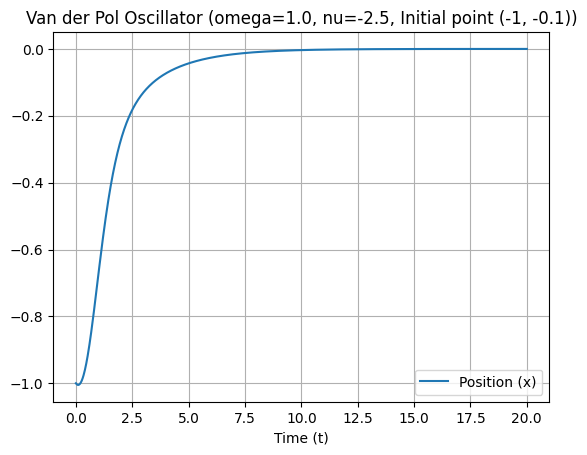

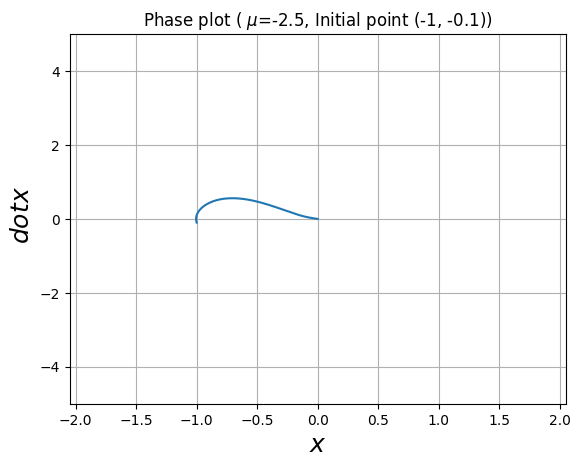

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from vdp import VDP

# 1. Define the physical parameters
omega = 1.0

nu = -2.5      # Non-linear damping parameter

# 2. Instantiate the VDP physics object
vdp_system = VDP(nu)

# 3. Set up the time domain and initial conditions
t_array = np.linspace(0, 20, 1000) # 1000 time steps from 0 to 20 seconds
initial_conditions = [-1, -0.1]    # [Starting position x=1.0, Starting velocity v=0.0]

# 4. Generate the exact trajectory data using RK4
trajectory = vdp_system.generate_trajectory(initial_conditions, t_array)

# Extract position (x) and velocity (v) from the results
x_data = trajectory[:, 0]
v_data = trajectory[:, 1]

# 5. Plot the result to verify
plt.plot(t_array, x_data, label="Position (x)")

# plt.plot(t_array, v_data, label="Velocity (v)")
plt.title(f"Van der Pol Oscillator (omega={omega}, nu={nu}, Initial point {initial_conditions[0],initial_conditions[1]})")
plt.xlabel("Time (t)")
plt.legend()
plt.grid()
plt.show()

#6. Plot phase plot
plt.title(f"Phase plot ( $\mu$={nu}, Initial point {initial_conditions[0],initial_conditions[1]})")
plt.plot(x_data,v_data)
plt.xlabel("$x$", fontsize=18)
plt.ylabel("$\ dot x$", fontsize=18)
plt.xlim(-2.05,2.05)
plt.ylim(-5,5)
plt.grid()
plt.show()

/mnt/c/Users/Abdul/Documents/Nagaoka Uni/Nagaoka Master/M1/Code/test/vdp.py:25: RuntimeWarning: overflow encountered in scalar multiply
  fv = -self.omega**2 * x + self.nu * (1 - x**2) * v
/mnt/c/Users/Abdul/Documents/Nagaoka Uni/Nagaoka Master/M1/Code/test/vdp.py:25: RuntimeWarning: overflow encountered in scalar power
  fv = -self.omega**2 * x + self.nu * (1 - x**2) * v
/mnt/c/Users/Abdul/Documents/Nagaoka Uni/Nagaoka Master/M1/Code/test/vdp.py:25: RuntimeWarning: invalid value encountered in scalar add
  fv = -self.omega**2 * x + self.nu * (1 - x**2) * v
/mnt/c/Users/Abdul/Documents/Nagaoka Uni/Nagaoka Master/M1/Code/test/vdp.py:44: RuntimeWarning: invalid value encountered in add
  return (k1 + 2*k2 + 2*k3 + k4) / 6.0


<function matplotlib.pyplot.show(close=None, block=None)>

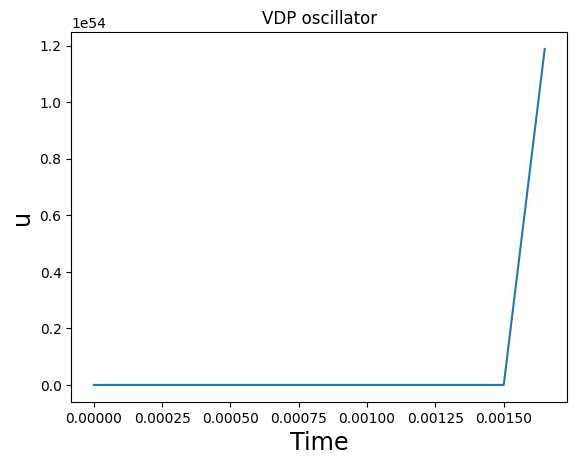

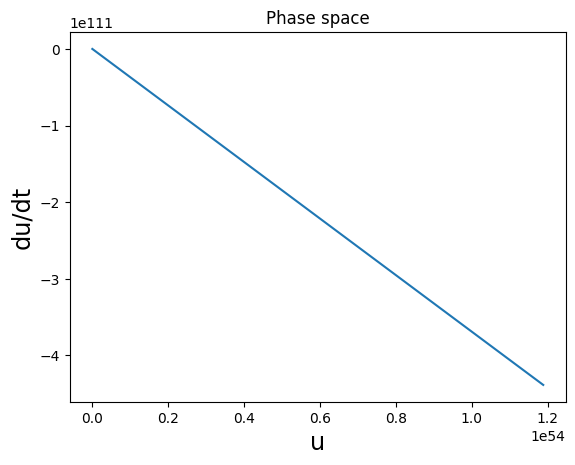

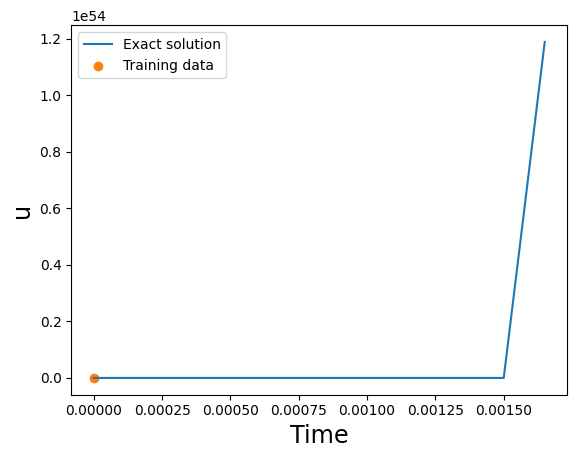

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from vdp import VDP
import torch

# We define the time step for RK4 numerical integration ... is important also for visualization
nSteps=10000
#Define omega0 and nu parameters .................
# 1. Define the physical parameters
omega = 1.0
nu = 2.5      # Non-linear damping parameter

# 2. Instantiate the VDP physics object
vdp_system = VDP(omega, nu)

# We integrate between tMin and tMax .............
tMin,tMax = 0.0,1.5
tStep = (tMax-tMin)/nSteps

tPoints = np.arange(tMin, tMax, tStep)
xPoints,vPoints = [],[]

# set initial conditions on the state variables ..........
x0,v0 = 1.,0.
r = np.array([x0,v0], float)

# solve for the time evolution for the true solution obtained with Runge-kutta of order 4 integration
for t in tPoints:
    xPoints += [r[0]]
    vPoints += [r[1]]
    r += vdp_system.rk4_step(r, t, tStep)

# plot displacement vs time  (true solution)  
fig1 = plt.figure(1)
plt.plot(tPoints, xPoints)
plt.xlabel("t")
plt.ylabel("u")
plt.xlabel("Time",fontsize="xx-large")
plt.ylabel("u",fontsize="xx-large")
plt.title("VDP oscillator")


x=torch.Tensor(tPoints).view(-1,1)
y=torch.Tensor(xPoints).view(-1,1)

# We select only some points (one over 10 for example) for future comparison with true solution
x = x[::10]
y = y[::10, :]

# We select a very few data points to be used in the normal Neural netwok -> training data ...
x_data=x[0:20:20]
y_data=y[0:20:20]

# plot the phase space (true solution)
fig2 = plt.figure(2)
plt.plot(xPoints, vPoints)
plt.xlabel("u",fontsize="xx-large")
plt.ylabel("du/dt",fontsize="xx-large")
plt.title("Phase space")

# We plot data of the true solution and the training data .............................
plt.figure()
plt.plot(tPoints, xPoints, label="Exact solution")
plt.xlabel("Time",fontsize="xx-large")
plt.ylabel("u",fontsize="xx-large")
plt.scatter(x_data, y_data, color="tab:orange", label="Training data")
plt.legend()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

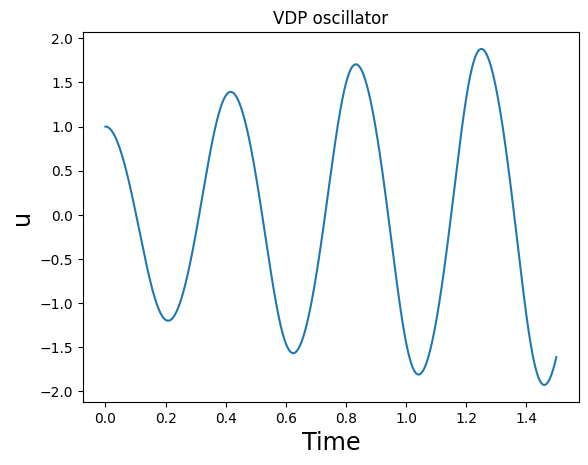

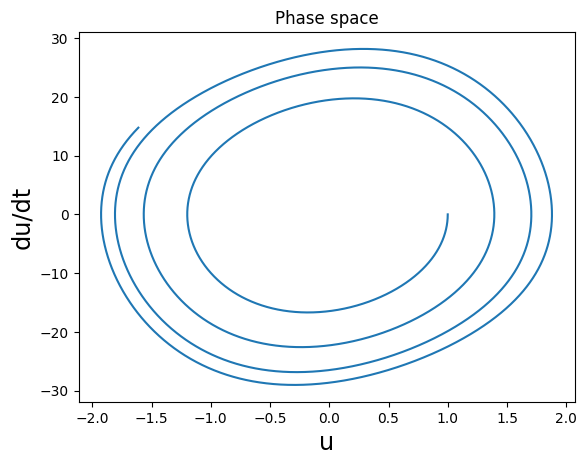

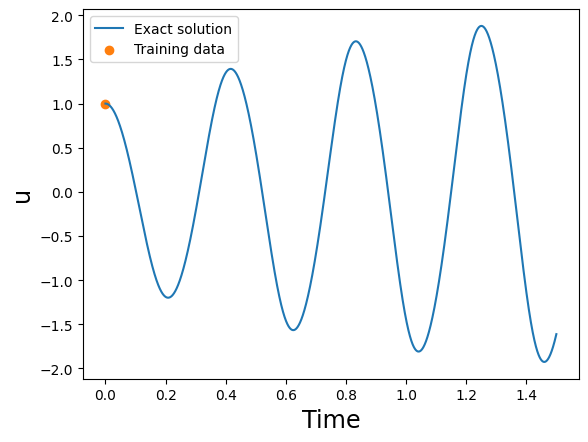

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from vdp import VDP
import torch

def runge_kutta4(func, r, t, omega, nu, h):
    """ 
    Runge-Kutta 4 method for solving 1st order differential equations
    
    Usage: xNew = rk4(func, r, t, h) 
    
    Given a function  f(x, t, h) = dx/dt and initial starting 
    conditions for x, rk4() returns the next values of x. 
    func:  user defined function for the 1st order differential equations
    r: dependent variable(s)
    t: independent variable(s)
    h: independent variable step value
    """
    k1 = h*func(r, t, omega, nu)
    k2 = h*func(r+0.5*k1, t+0.5*h, omega, nu)
    k3 = h*func(r+0.5*k2, t+0.5*h, omega, nu)
    k4 = h*func(r+k3, t+h, omega, nu)
    return (k1 + 2*k2 + 2*k3 + k4)/6
   
def pendule_Function(r, t, omega, nu):
    """ vectorized function for the pendule """
    x = r[0]
    v = r[1]
    fx = v
    fv = -omega**2 * x  +  nu*(1 - x**2)*v
    return np.array([fx,fv], float)

# We define the time step for RK4 numerical integration ... is important also for visualization
nSteps=10000
#Define omega0 and nu parameters .................
w0 = 15.
nu=2.5        # This is epsilon * w0 (nu = 5 -> epsilon = 1/3) ...................

# We integrate between tMin and tMax .............
tMin,tMax = 0.0,1.5
tStep = (tMax-tMin)/nSteps

tPoints = np.arange(tMin, tMax, tStep)
xPoints,vPoints = [],[]

# set initial conditions on the state variables ..........
x0,v0 = 1.,0.
r = np.array([x0,v0], float)

# solve for the time evolution for the true solution obtained with Runge-kutta of order 4 integration
for t in tPoints:
    xPoints += [r[0]]
    vPoints += [r[1]]
    r += runge_kutta4(pendule_Function, r, t, w0, nu, tStep)

# plot displacement vs time  (true solution)  
fig1 = plt.figure(1)
plt.plot(tPoints, xPoints)
plt.xlabel("t")
plt.ylabel("u")
plt.xlabel("Time",fontsize="xx-large")
plt.ylabel("u",fontsize="xx-large")
plt.title("VDP oscillator")


x=torch.Tensor(tPoints).view(-1,1)
y=torch.Tensor(xPoints).view(-1,1)

# We select only some points (one over 10 for example) for future comparison with true solution
x = x[::10]
y = y[::10, :]

# We select a very few data points to be used in the normal Neural netwok -> training data ...
x_data=x[0:20:20]
y_data=y[0:20:20]

# plot the phase space (true solution)
fig2 = plt.figure(2)
plt.plot(xPoints, vPoints)
plt.xlabel("u",fontsize="xx-large")
plt.ylabel("du/dt",fontsize="xx-large")
plt.title("Phase space")

# We plot data of the true solution and the training data .............................
plt.figure()
plt.plot(tPoints, xPoints, label="Exact solution")
plt.xlabel("Time",fontsize="xx-large")
plt.ylabel("u",fontsize="xx-large")
plt.scatter(x_data, y_data, color="tab:orange", label="Training data")
plt.legend()
plt.show

In [2]:
def plot_result(x,y,x_data,y_data,yh,xp=None):
    "Pretty plot training results"
    plt.figure(figsize=(8,4))
    plt.plot(x,yh, color="tab:red", linewidth=2, alpha=0.8, label="NN prediction")
    plt.plot(x,y, color="blue", linewidth=2, alpha=0.8, linestyle='--', label="Exact solution")
    plt.scatter(x_data, y_data, s=60, color="tab:orange", alpha=0.4, label='Training data')
    if xp is not None:
        plt.scatter(xp, -0*torch.ones_like(xp), s=30, color="tab:green", alpha=0.4, 
                    label='Colloc. points')
    l = plt.legend(loc=(0.701,0.14), frameon=False, fontsize="large")
    plt.setp(l.get_texts(), color="k")
    plt.xlim(-0.05,2.15)
    plt.ylim(-2.3, 2.3)
    plt.text(1.525,0.9,"Step: %i"%(i+1),fontsize="xx-large",color="k")
    plt.ylabel('u',fontsize="xx-large")
    plt.xlabel('Time',fontsize="xx-large")
    plt.axis("on")

RAISI METHOD

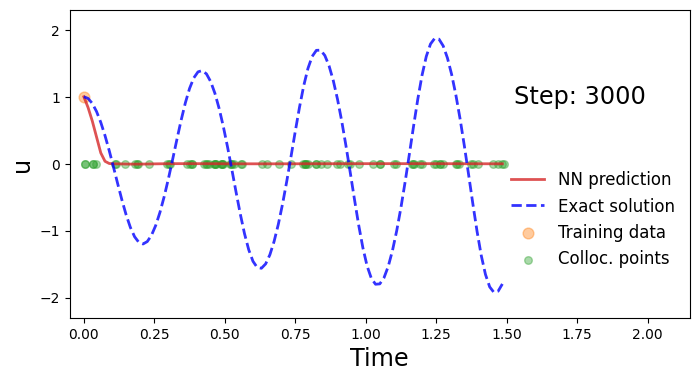

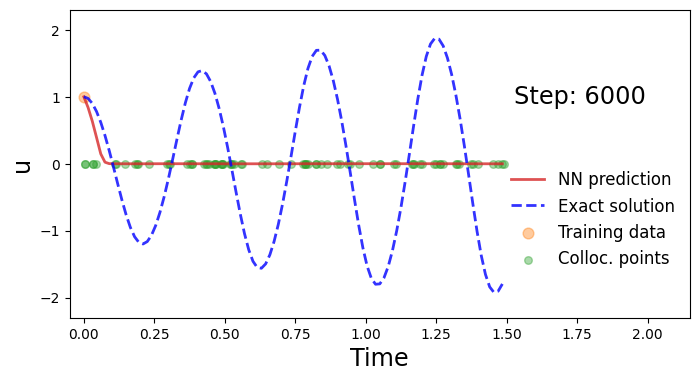

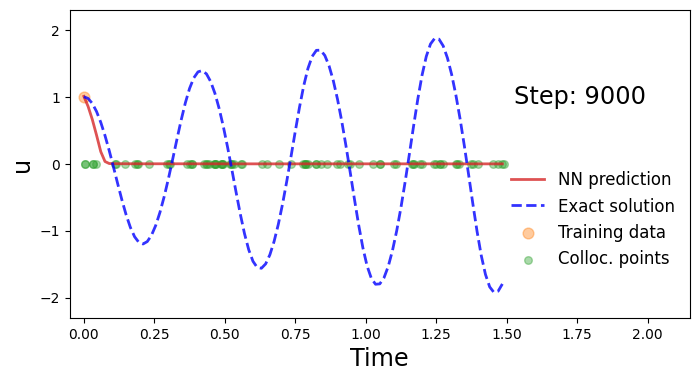

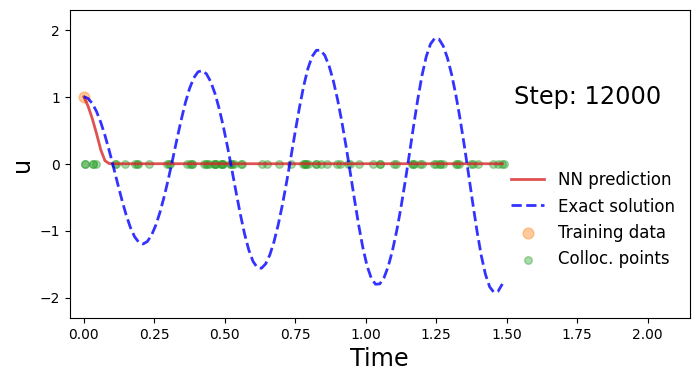

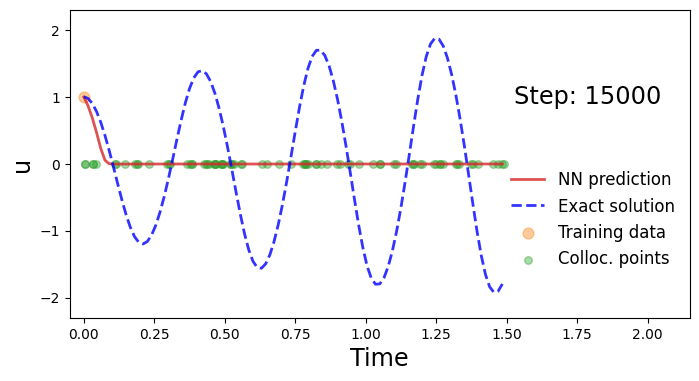

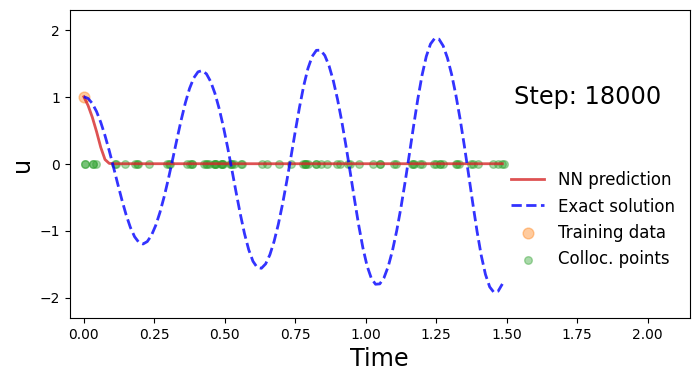

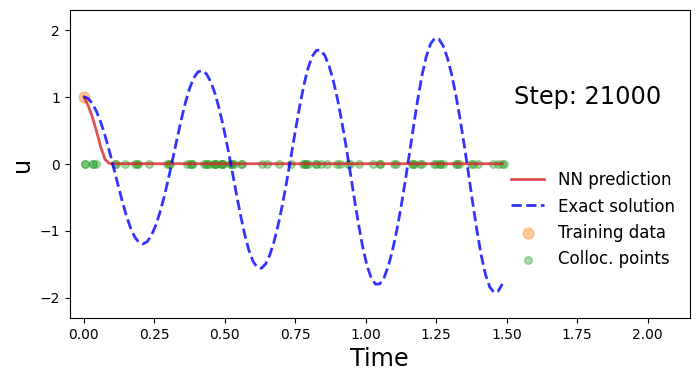

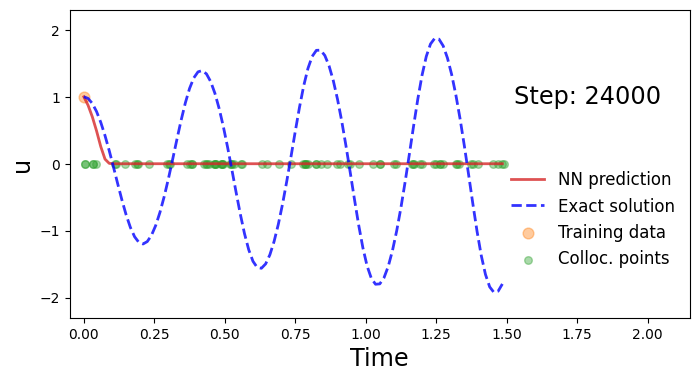

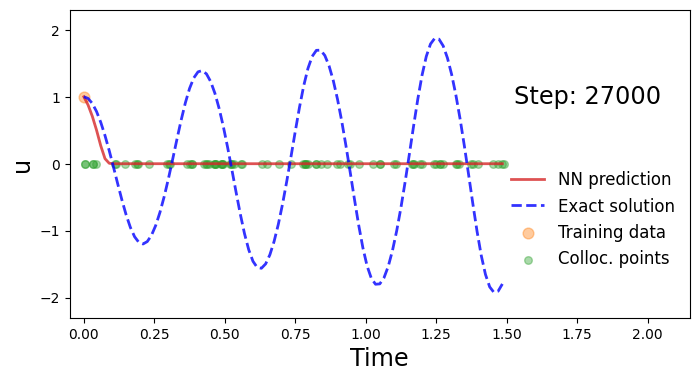

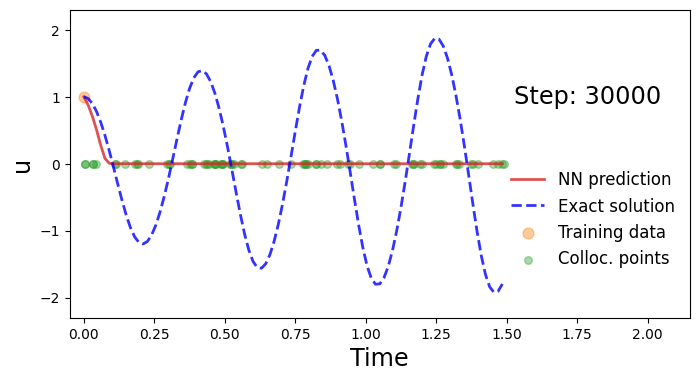

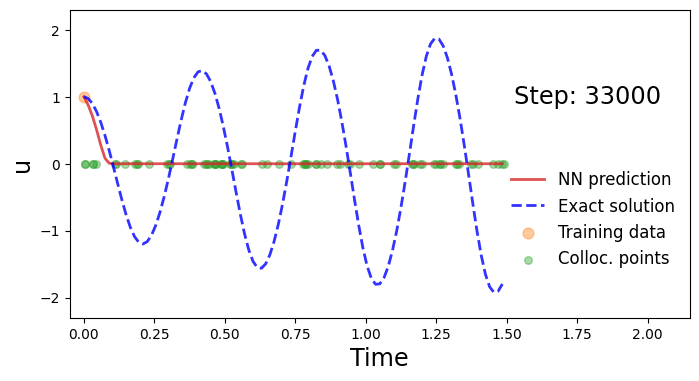

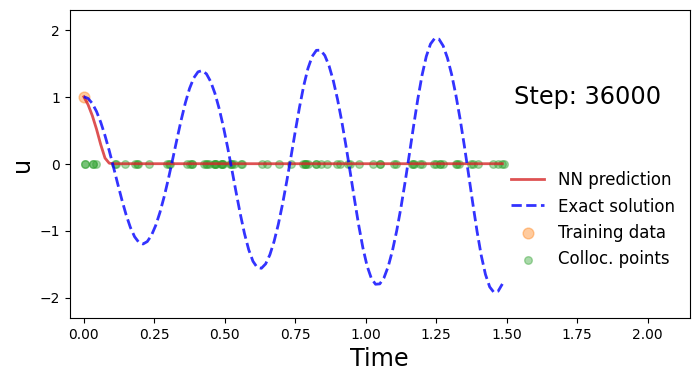

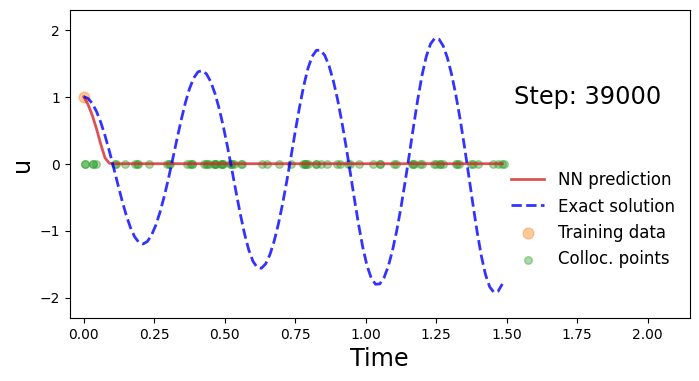

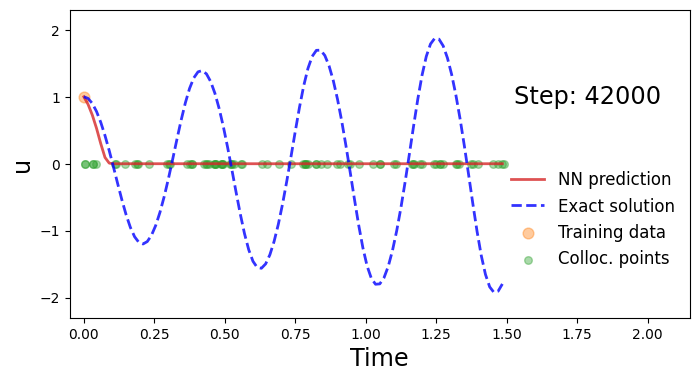

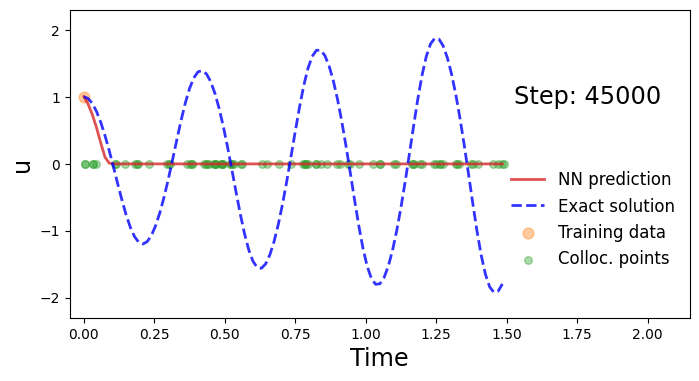

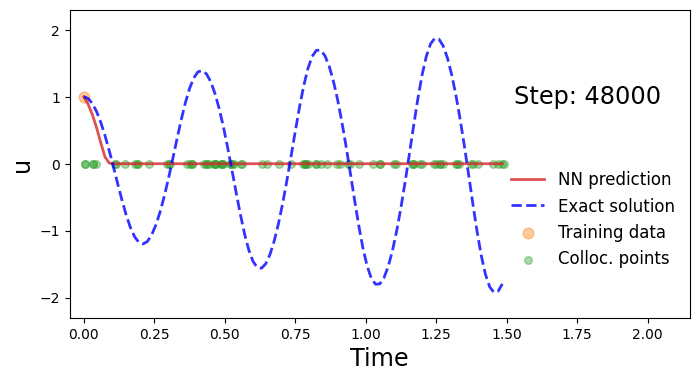

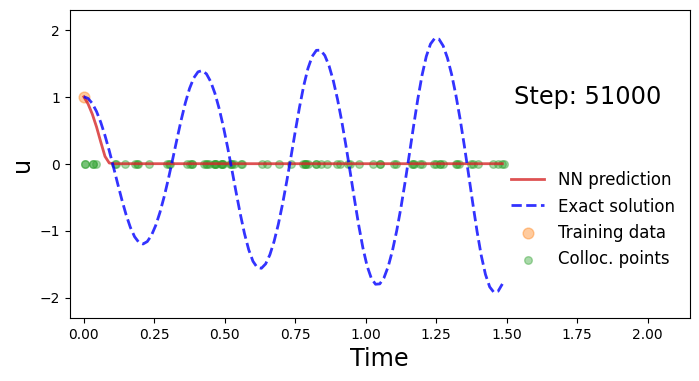

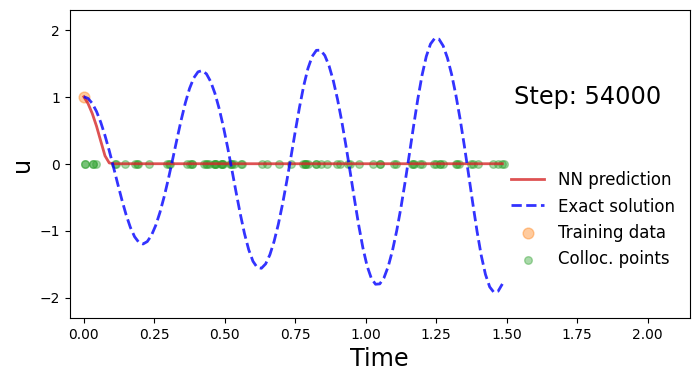

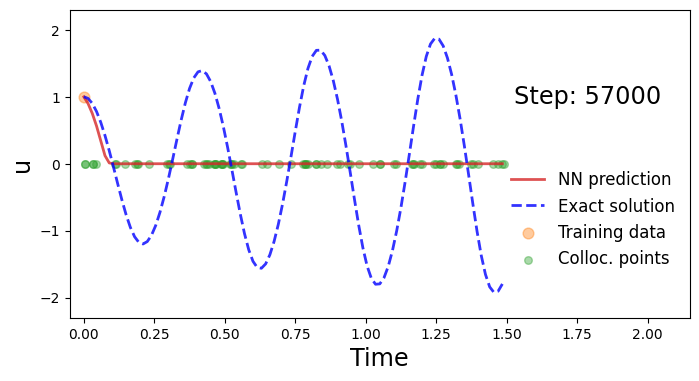

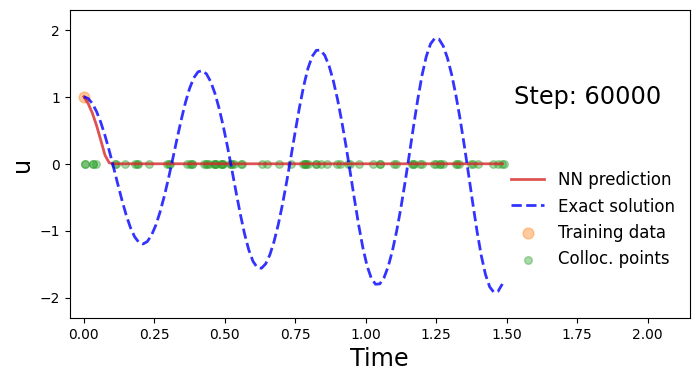

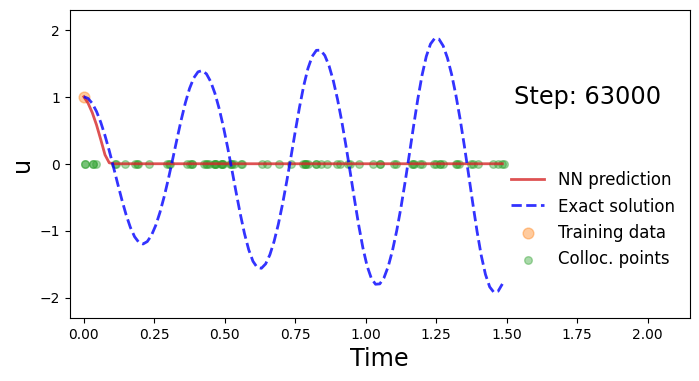

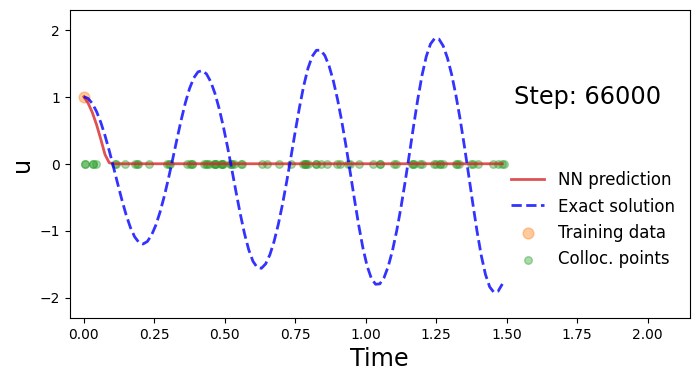

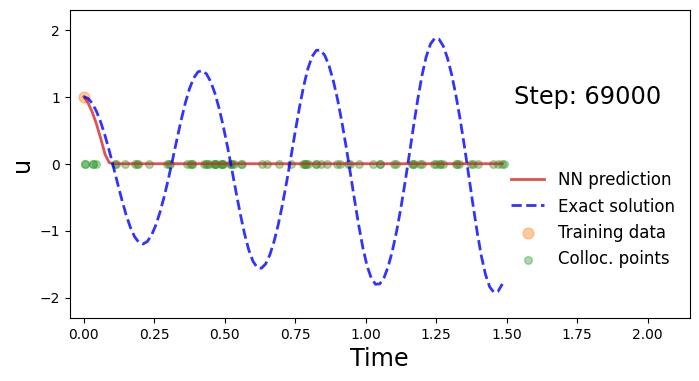

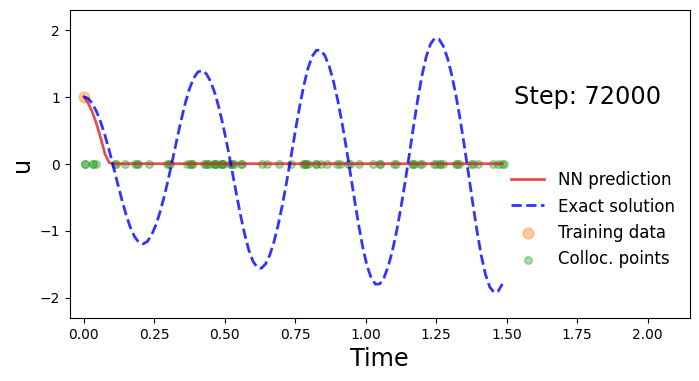

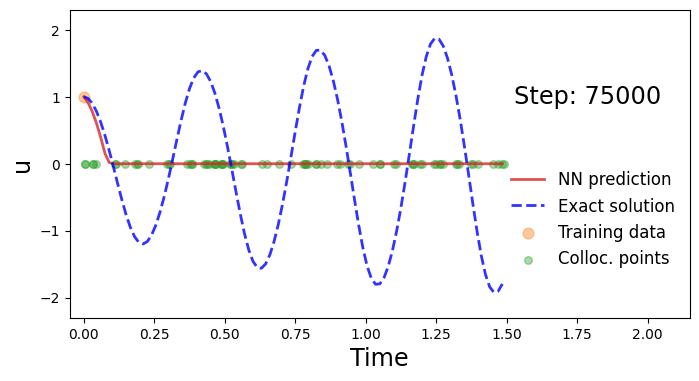

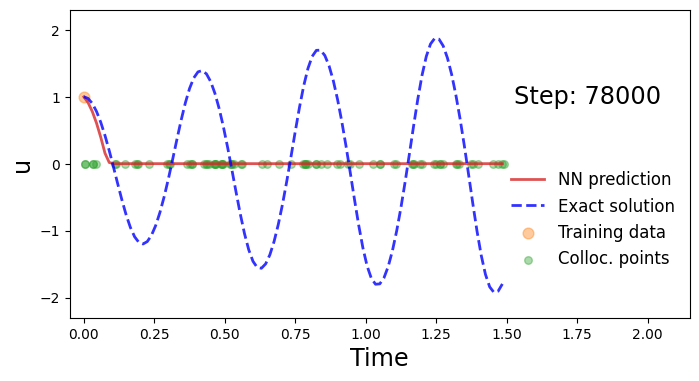

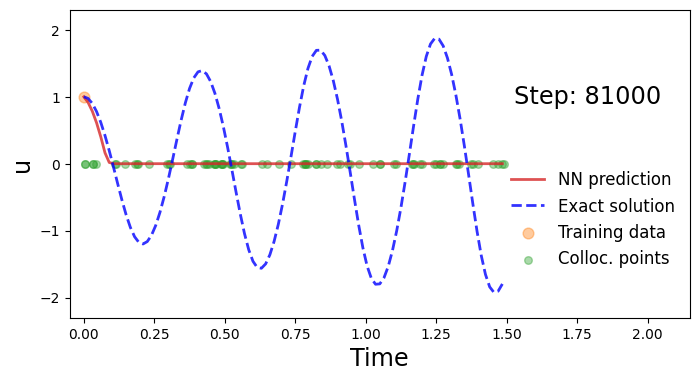

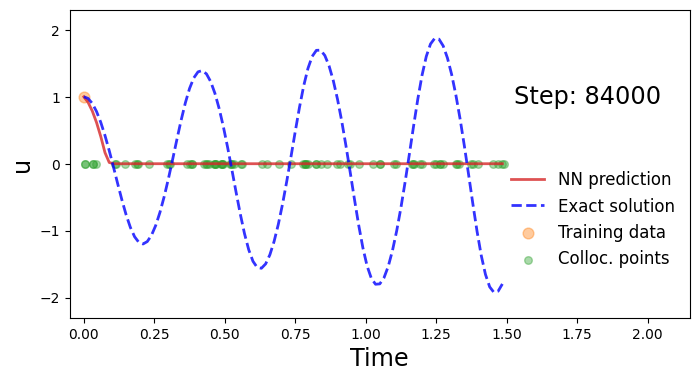

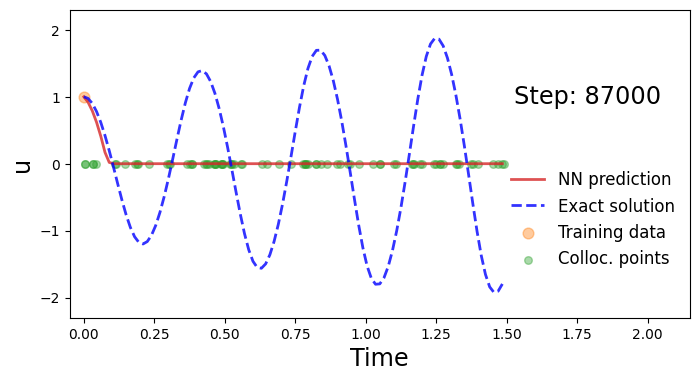

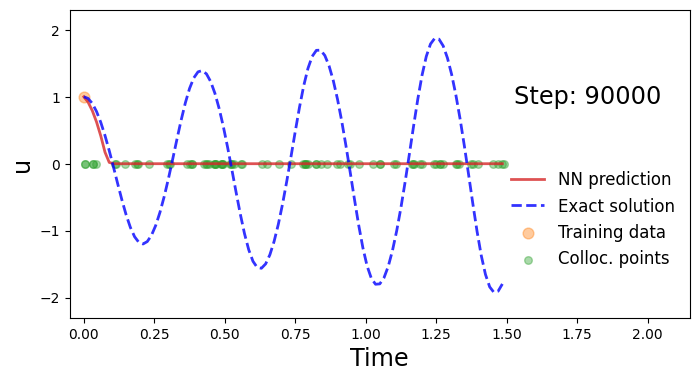

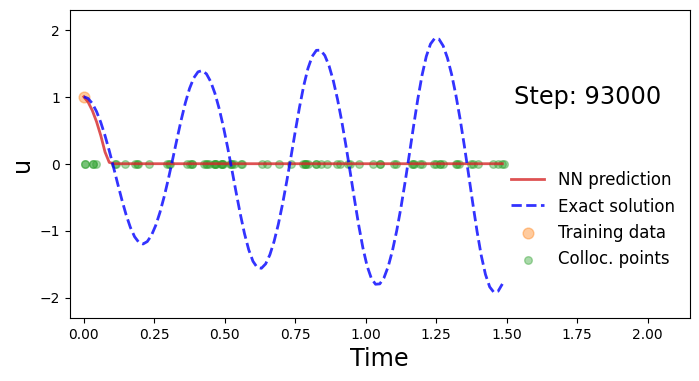

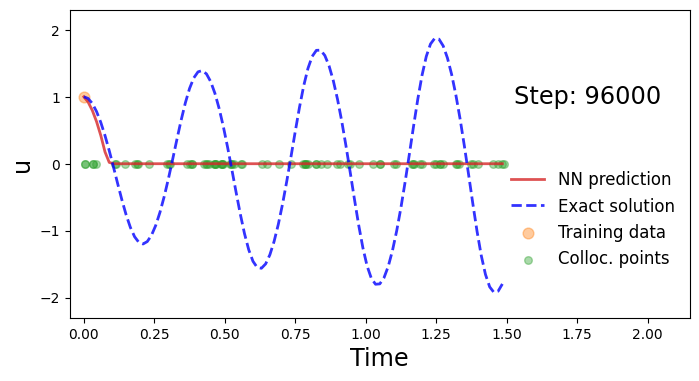

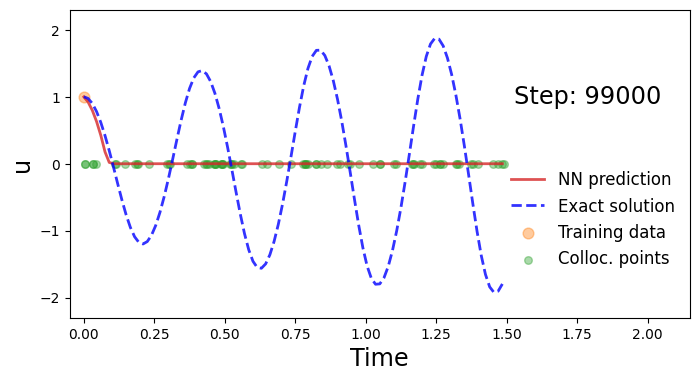

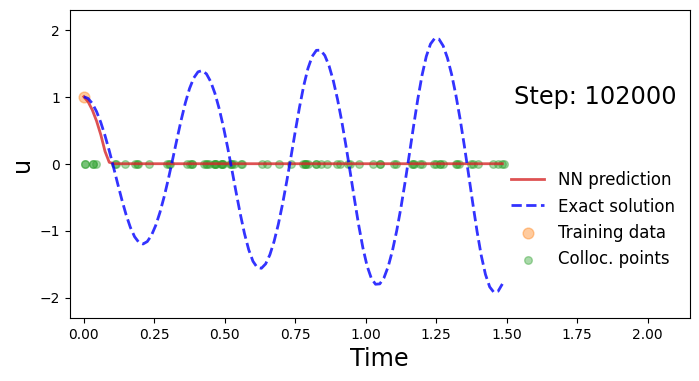

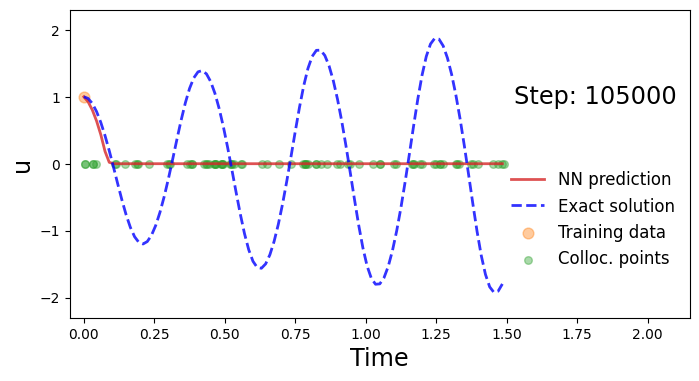

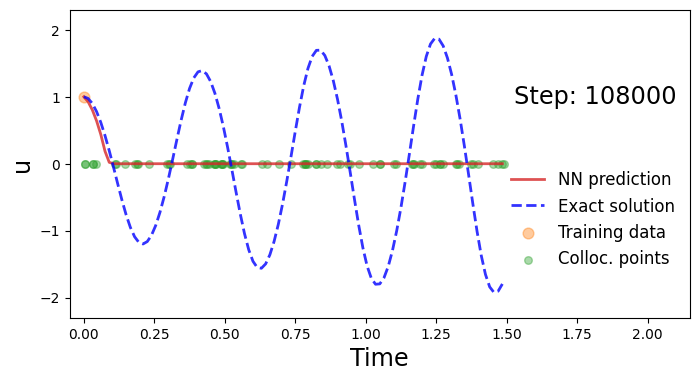

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from vdp import VDP
from pinn import FCN

#Define omega0 and nu parameters .................
w0 = 15.
nu=2.5 

#Raisi Method
N_colloc = 80
t_min =0.0
t_max = 1.5

# We select only some points (one over 10 for example) for future comparison with true solution
x = x[::10]
y = y[::10, :]

# We select a very few data points to be used in the normal Neural netwok -> training data ...
x_train_data=x[0:20:20]
y_train_data=y[0:20:20]
# ...................
ww=w0
torch.manual_seed(125)
model = FCN(1,1,42,4)

x_physics = (t_min + (t_max - t_min) * torch.rand(N_colloc, 1)).requires_grad_(True) #COLLOCATION POINTS RAISI

optimizer = torch.optim.Adam(model.parameters(),lr=7e-4)
files = []
loss1_history = []
loss2_history = []
loss_history = []
mse_history = []

for i in range(109000):
    # the range of colocation points is increasing with a moving right boundary .....
    # lim=0.2 + np.minimum(1.3*i/74000.,1.3)       
    # x_physics = torch.linspace(0.,lim,80).view(-1,1).requires_grad_(True)#
    
    # x_physics = (t_min + (t_max - t_min) * torch.rand(N_colloc, 1)).requires_grad_(True)

    optimizer.zero_grad()
        
    # compute the first part of the "data loss" .....
    yh = model(x_train_data)
    loss1 = 1*torch.mean((yh-y_train_data)**2)  # use mean squared error (the weight is taken to be 1)
    
    # compute the "physics loss" with enforcing the initial data ........................
    yhp = model(x_physics)
    # compute first and second derivatives by automatic differentiation .........................
    dx  = torch.autograd.grad(yhp, x_physics, torch.ones_like(yhp), create_graph=True)[0]# computes dy/dx
    dx2 = torch.autograd.grad(dx,  x_physics, torch.ones_like(dx),  create_graph=True)[0]# computes d^2y/dx^2
    
    # second part of loss1 .............
    loss1 = loss1 + 0.1*torch.max((dx[0])**2)
    
    # computes the equation residual ........................................
    physics= (dx2 + ww**2*yhp - nu*(1 - yhp*yhp)*dx)   # This is the equation ................
    loss2 = (1e-4)*torch.mean(physics**2)    # Loss on physics with a chosen weight ..........
    yhpp=model(x)
    mse=torch.mean((yhpp-y)**2)   # compute mean square error using exact solution ............

    # backpropagate the total loss .......................................................
    loss = loss1 + loss2  # add two loss terms together ..................................
    loss.backward()
    optimizer.step()    
        
    # plot the result as training progresses ...............................
    if (i+1) % 100 == 0: 
        loss1_history.append(loss1.detach())
        loss2_history.append(loss2.detach())
        loss_history.append(loss.detach())
        
        yh = model(x).detach()
        xp = x_physics.detach()
        
        yhpp=model(x)
        mse=torch.mean((yhpp-y)**2)   # compute mean square error using exact solution .....
        mse_history.append(mse.detach())

        
        plot_result(x,y,x_data,y_train_data,yh,xp)
           
        if (i+1) % 3000 == 0: plt.show()
        else: plt.close("all")

<div class="alert alert-block alert-warning">
<b>L-BFGS:</b>Use different optimizer
</div>

In [ ]:
    import matplotlib.pyplot as plt
    import numpy as np
    from vdp import VDP
    from pinn import FCN

    #Define omega0 and nu parameters .................
    w0 = 15.
    nu=2.5 
    # We select only some points (one over 10 for example) for future comparison with true solution
    x = x[::10]
    y = y[::10, :]

    # We select a very few data points to be used in the normal Neural netwok -> training data ...
    x_train_data=x[0:20:20]
    y_train_data=y[0:20:20]
    # ...................
    ww=w0
    torch.manual_seed(125)
    model = FCN(1,1,42,4)

    optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)
    files = []
    loss1_history = []
    loss2_history = []
    loss_history = []
    mse_history = []
    total_colloc_point = 0

    for i in range(10000):
        # the range of colocation points is increasing with a moving right boundary .....
        lim=0.2 + np.minimum(1.3*i/7000.,1.3)       
        x_physics = torch.linspace(0.,lim,80).view(-1,1).requires_grad_(True)#
        total_colloc_point += x_physics.shape[0]
        optimizer.zero_grad()
            
        # compute the first part of the "data loss" .....
        yh = model(x_train_data)
        loss1 = 1*torch.mean((yh-y_train_data)**2)  # use mean squared error (the weight is taken to be 1)
        
        # compute the "physics loss" with enforcing the initial data ........................
        yhp = model(x_physics)
        # compute first and second derivatives by automatic differentiation .........................
        dx  = torch.autograd.grad(yhp, x_physics, torch.ones_like(yhp), create_graph=True)[0]# computes dy/dx
        dx2 = torch.autograd.grad(dx,  x_physics, torch.ones_like(dx),  create_graph=True)[0]# computes d^2y/dx^2
        
        # second part of loss1 .............
        loss1 = loss1 + 0.1*torch.max((dx[0])**2)
        
        # computes the equation residual ........................................
        physics= (dx2 + ww**2*yhp - nu*(1 - yhp*yhp)*dx)   # This is the equation ................
        loss2 = (1e-4)*torch.mean(physics**2)    # Loss on physics with a chosen weight ..........
        yhpp=model(x)
        mse=torch.mean((yhpp-y)**2)   # compute mean square error using exact solution ............

        # backpropagate the total loss .......................................................
        loss = loss1 + loss2  # add two loss terms together ..................................
        loss.backward()
        optimizer.step()    
            
        # plot the result as training progresses ...............................
        if (i+1) % 100 == 0: 
            loss1_history.append(loss1.detach())
            loss2_history.append(loss2.detach())
            loss_history.append(loss.detach())
            
            yh = model(x).detach()
            xp = x_physics.detach()
            
            yhpp=model(x)
            mse=torch.mean((yhpp-y)**2)   # compute mean square error using exact solution .....
            mse_history.append(mse.detach())

            
            plot_result(x,y,x_data,y_train_data,yh,xp)
            
            if (i+1) % 2000 == 0: plt.show()
            else: plt.close("all")


    final_mse = mse_history[-1].item()
    print(f"Final MSE: {final_mse:.6e}")
    print(f"Total collocation points: {total_colloc_point}")

RuntimeError: This is not allowed since there's already a kernel registered from python overriding wait_tensor's behavior for Autograd dispatch key and _c10d_functional namespace.